In [17]:
import numpy as np
import matplotlib.pyplot as plt

In [23]:
%matplotlib inline

In [24]:
N = 200
box_size = 10.0
radius = 2.0
noise = 0.1
velocity = 0.5
frames = 50

pos = np.random.uniform(0, box_size, size=(N, 2))
angles = np.random.uniform(-np.pi, np.pi, size=N)

for _ in range(frames):
    dx = np.subtract.outer(pos[:, 0], pos[:, 0])
    dy = np.subtract.outer(pos[:, 1], pos[:, 1])

    dx = dx - box_size * np.round(dx / box_size)
    dy = dy - box_size * np.round(dy / box_size)

    distances = np.sqrt(dx**2 + dy**2)
    neighbor_mask = distances < radius

    adjacency_matrix = neighbor_mask.astype(int)
    sum_sines = np.dot(adjacency_matrix, np.sin(angles))
    sum_cosines = np.dot(adjacency_matrix, np.cos(angles))
    avg_angles = np.arctan2(sum_sines, sum_cosines)

    angles = avg_angles + np.random.uniform(-noise/2, noise/2, size=N)
    pos[:, 0] += velocity * np.cos(angles)
    pos[:, 1] += velocity * np.sin(angles)
    positions = pos % box_size

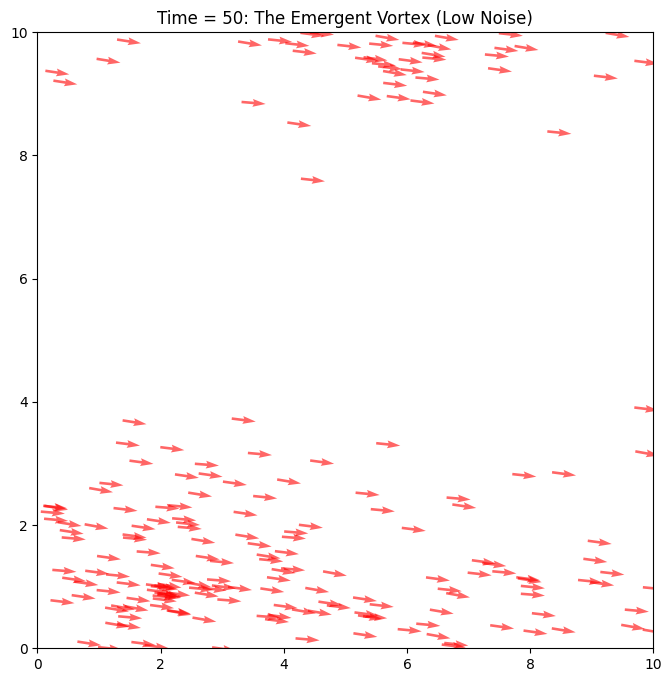

In [26]:
fig, ax = plt.subplots(figsize=(8, 8))
u = np.cos(angles)
v = np.sin(angles)
ax.quiver(positions[:, 0], positions[:, 1], u, v, alpha=0.6, color='red')
ax.set_xlim(0, box_size)
ax.set_ylim(0, box_size)
ax.set_title(f"Time = {frames}: The Emergent Vortex (Low Noise)")
ax.set_aspect('equal')

plt.show()